- https://chatgpt.com/share/696e5dfd-fe60-800d-a69d-9bab3581292f
- https://chatgpt.com/share/69722371-c848-800d-97d7-4b535e56a7c8
- https://www.geeksforgeeks.org/machine-learning/gradient-descent-in-linear-regression/

In [3]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [6]:
X,y = make_regression(n_samples=100,n_features=1,noise=20,random_state=13,n_targets=1,n_informative=1)

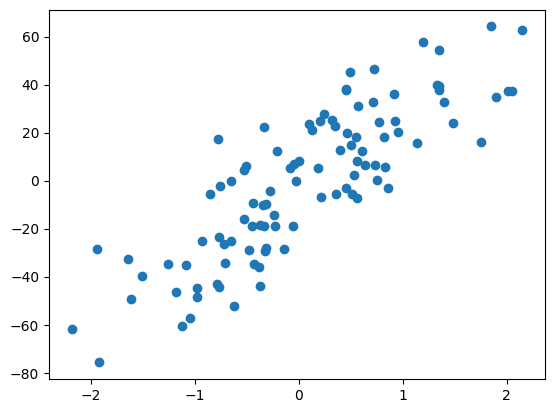

In [7]:
plt.scatter(X,y)

In [208]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=13)

In [209]:
from sklearn.linear_model import LinearRegression

In [210]:
lr = LinearRegression()

In [211]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [212]:
print(lr.coef_,lr.intercept_)

[28.67684216] -2.088699766134101


In [213]:
y_pred = lr.predict(X_test)

In [214]:
from sklearn.metrics import r2_score

In [215]:
r2_score(y_test,y_pred)

0.71337703667083

- loss funtion for slope
- ∂b / ∂J = −2∑(y−(mx+b)) || −2∑(y−mx-b)
- 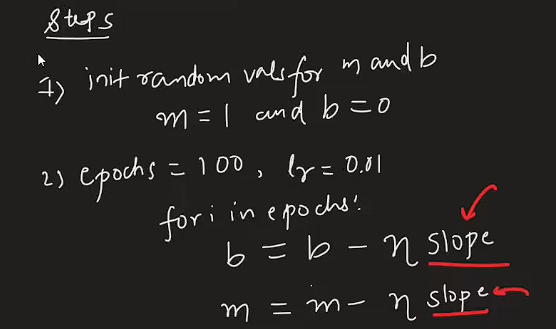

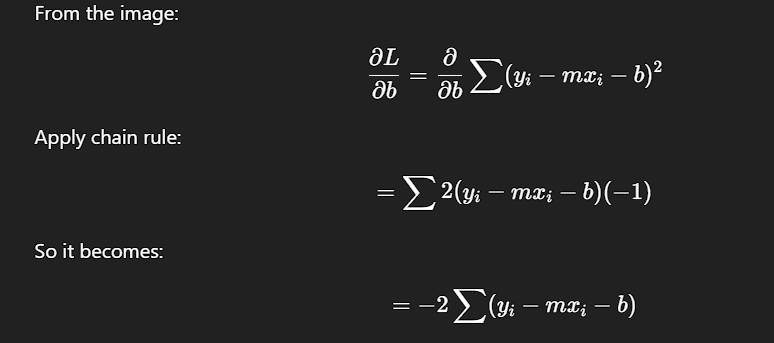
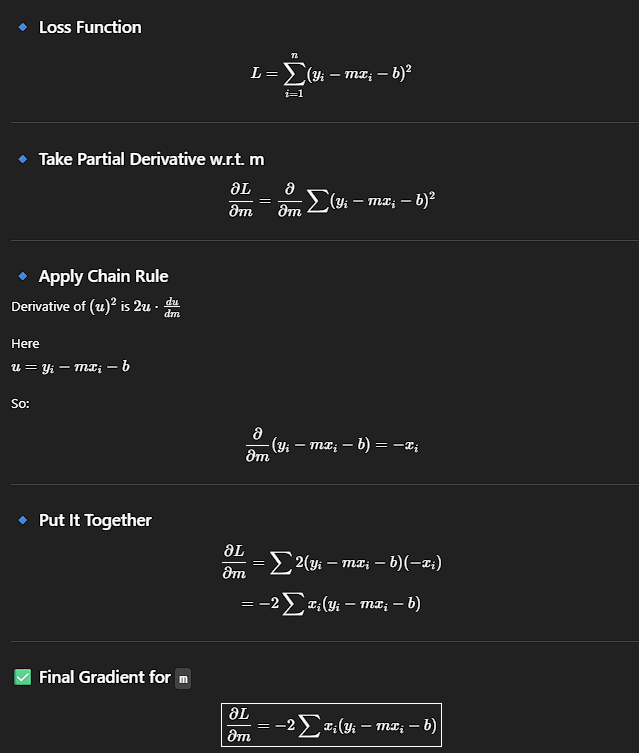

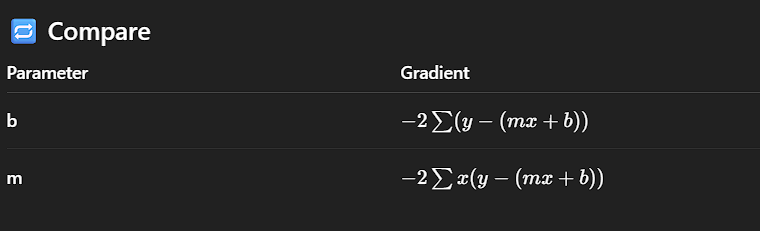

In [216]:
class GDRegressor:
    def __init__(self,learning_rate,epochs):
      self.lr = learning_rate
      self.epochs = epochs
      self.coef_ = 0 # m
      self.intercept_ = 1 # b
        
    def fit(self,X_train,y_train):
      for _ in range(self.epochs):
          # loss_slope_b = -2 * np.sum(y_train - (self.coef_ * X_train.ravel() + self.intercept_))
          loss_slope_b = -2 * np.sum(y_train - self.coef_ * X_train.ravel() - self.intercept_)
          self.intercept_ = self.intercept_ - (self.lr * loss_slope_b)
          # New intercept = Old intercept − (learning rate × gradient(slop))
          
          # loss_slope_m = -2 * np.sum((y_train - (self.coef_ * X_train.ravel() + self.intercept_)) * X_train.ravel())
          loss_slope_m = -2 * np.sum((y_train - self.coef_ * X_train.ravel() - self.intercept_) * X_train.ravel())
          self.coef_ = self.coef_ - (self.lr * loss_slope_m)
          # New coef_ = Old coef_ − (learning rate × gradient(slop))
          
      print(self.coef_,self.intercept_)

    def predict(self,X_train):
        return self.intercept_ + self.coef_ * X_train

In [217]:
gd = GDRegressor(0.001,100)
# gd = GDRegressor(0.001,50)

In [218]:
gd.fit(X_train,y_train)

28.67680950823849 -2.0887082068313965


In [219]:
y_pred = gd.predict(X_test)

In [220]:
r2_score(y_test,y_pred) # 0.71337703667083

0.713377393066195

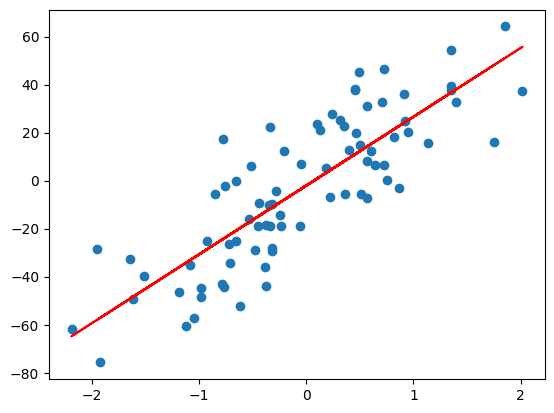

In [221]:
plt.scatter(X_train,y_train)
plt.plot(X_train,gd.predict(X_train),color='red')